In [641]:
import numpy as np
import csv
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import cv2

In [642]:
import camera_tools as ct

In [643]:
#Use this function to calculate Y (angular) position errors 
# Y (angular) positions
def readAngleFilesAndCollectErrors(fileName):
    angleDataFrame = pd.read_csv(fileName)
    desired_column = angleDataFrame.columns[0]
    angle_error_list = []
    for i in range(1,len(angleDataFrame)):
        current_data_element = angleDataFrame[desired_column][i]
        previous_data_element = angleDataFrame[desired_column][i-1]
        #TODO???: Calculate the Y (angular) position error(say current_error) as the difference between 
        # the current Y (angular) position and previous Y (angular) position
        current_error = current_data_element - previous_data_element
        #print(current_data_element," ", previous_data_element, " ", current_error)
        angle_error_list = angle_error_list + [current_error]
    return angle_error_list

In [644]:
#Use this function to calculate errors between x and y coordinates
def readXYCoordsFilesAndCollectErrors(fileName):
    xyCoordsDataFrame = pd.read_csv(fileName)
    x_col_name = xyCoordsDataFrame.columns[0]
    y_col_name = xyCoordsDataFrame.columns[1]
    x_pos_error_list = []
    y_pos_error_list = []
    for i in range(1,len(xyCoordsDataFrame)):
        current_data_element_x = xyCoordsDataFrame[x_col_name][i]
        current_data_element_y = xyCoordsDataFrame[y_col_name][i]
        previous_data_element_x = xyCoordsDataFrame[x_col_name][i-1]
        previous_data_element_y = xyCoordsDataFrame[y_col_name][i-1]
        error_x_pos = current_data_element_x - previous_data_element_x 
        error_y_pos = current_data_element_y - previous_data_element_y
        x_pos_error_list = x_pos_error_list + [error_x_pos]
        y_pos_error_list = y_pos_error_list + [error_y_pos] 
    return [x_pos_error_list,y_pos_error_list]

In [645]:
#Read the provided files and load the calculated errors into to appropriate lists as follows
angle_error_list_1 = readAngleFilesAndCollectErrors("angles_1.csv")
x_pos_error_list_1,y_pos_error_list_1 = readXYCoordsFilesAndCollectErrors("xyCoords_1.csv")
#Read the files with the data dumped by you and load the calculated errors into appropriate lists.
angle_error_list_2 = readAngleFilesAndCollectErrors("angles_2.csv")
x_pos_error_list_2,y_pos_error_list_2 = readXYCoordsFilesAndCollectErrors("xyCoords_2.csv")

In [646]:
#merge both angle_error_list_1 and angle_error_list_2 to a single list and make it a numpy array called 'angle_error_array'
angle_error_array = np.array(angle_error_list_1 + angle_error_list_2 )
#merge both x_pos_error_list_1 and x_pos_error_list_2 to a single list and make it a numpy array called 'x_coord_error_array'
x_coord_error_array = np.array(x_pos_error_list_1 + x_pos_error_list_2)
#merge both y_pos_error_list_1 and y_pos_error_list_2 to a single list and make it a numpy array called 'y_coord_error_array'
y_coord_error_array = np.array(y_pos_error_list_1 + y_pos_error_list_2)

In [647]:
# Here we use 80% of the collected data  as the training set and 20% of the collected data as test set.
#TODO: Assign different propotions of the collected data set and test set and check how the test set error varies of the 
#Neural Network
data =  np.vstack((x_coord_error_array,y_coord_error_array)).T
target = np.vstack(angle_error_array)
data_input_tensor = torch.tensor(data.tolist()).float()
data_target_tensor = torch.tensor(target.tolist()).float()
data_with_target = torch.cat((data_input_tensor,data_target_tensor),1)
#TODO: what is the importance of using DataLoader utility function here?
loader= torch.utils.data.DataLoader(data_with_target,
                                     batch_size=data_with_target.size()[0], shuffle=True,
                                     num_workers=0)
#training set
train_set = []
#test set
test_set = []
for i in iter(loader):
    train_set_index = (int)(np.round(i.shape[0]*0.8))
    train_set = i[:train_set_index,:]
    test_set = i[train_set_index:,:]

In [648]:
print(train_set.shape)
print(test_set.shape)

torch.Size([742, 3])
torch.Size([185, 3])


In [649]:
#Defining Neural Network Model
class NN(torch.nn.Module):
    def __init__(self,n_feature,n_hidden1,n_hidden2,n_output):
        super(NN,self).__init__()
        self.hidden1 = torch.nn.Linear(n_feature,n_hidden1)
        #self.do1 = torch.nn.Dropout(0.15)
        self.relu1 = torch.nn.LeakyReLU()
        self.bn1 = torch.nn.BatchNorm1d(n_hidden1,affine=False)
        self.hidden2 = torch.nn.Linear(n_hidden1,n_hidden2)
        self.bn2 = torch.nn.BatchNorm1d(n_hidden2,affine=False)
        self.relu2 = torch.nn.LeakyReLU()
        #self.do2 = torch.nn.Dropout(0.1)
        self.predict = torch.nn.Linear(n_hidden2,n_output)
        
        
    def forward(self,x):
        x = self.hidden1(x)
        x = torch.sigmoid(x)
        #x = self.do1(x)
        x = self.relu1(x)
        #x = self.bn1(x)
        x = self.hidden2(x)
        x = torch.sigmoid(x)
        #x = self.bn2(x)
        x = self.relu2(x)
        #x = self.do2(x)
        x = self.predict(x)
        return x

In [650]:
#instantiate the Neural Network
# model = NN(n_feature=2,n_hidden1=17,n_hidden2=7, n_output=1)      # 15.4
# model = NN(n_feature=2,n_hidden1=31,n_hidden2=13, n_output=1)     # 9.55
# model = NN(n_feature=2,n_hidden1=100,n_hidden2=100, n_output=1)   # 15.65
model = NN(n_feature=2,n_hidden1=100,n_hidden2=32, n_output=1)    # 7.98
# model = NN(n_feature=2,n_hidden1=65,n_hidden2=27, n_output=1)     # 8.24
# model = NN(n_feature=2,n_hidden1=65,n_hidden2=27, n_output=1)     # 10.7
# model = NN(n_feature=2,n_hidden1=82,n_hidden2=34, n_output=1)     # 8.58
# model = NN(n_feature=2,n_hidden1=82,n_hidden2=16, n_output=1)     # 8.42
# model = NN(n_feature=2,n_hidden1=100,n_hidden2=16, n_output=1)     # 8.47


In [651]:
32*32

1024

In [652]:
27+7

34

In [653]:
31+17+17+17

82

In [654]:
#Define loss function : 
# here we use Mean Square Error as the loss function
loss_func = torch.nn.MSELoss()

In [655]:
#Define the optimizer that should be used in training the Neural Network.
# Here 'lr' is the learning rate
optimizer = torch.optim.Adam(model.parameters(),lr=0.15)    # 7.98 with 2200 epochs, 7.7 with 20000 epochs
# optimizer = torch.optim.Adam(model.parameters(),lr=0.01)    # 7.49 with 7000 epochs, 7.33 with 10000 epochs
# optimizer = torch.optim.Adam(model.parameters(),lr=0.2)     # 12.01
# optimizer = torch.optim.Adam(model.parameters(),lr=0.001)    # 7.1 with 20000 epochs, 6.4 with 30000 epochs

In [656]:
train_set_inputs = train_set[:,:2]
#Calculate the mean value of the train_set_inputs. 
mean_of_train_input = torch.mean(train_set_inputs)
#standard deviation of the train set inputs.
std_of_the_train_input = torch.std(train_set_inputs,0)
#here we normalize the inputs of the neural network. What is the importance of that?
normalized_train_set_inputs = (train_set_inputs - mean_of_train_input)/std_of_the_train_input

In [657]:
#targets of the training set
train_set_targets = train_set[:,2][:,np.newaxis]

In [658]:
print(normalized_train_set_inputs.shape)
print(train_set_targets.shape)

torch.Size([742, 2])
torch.Size([742, 1])


In [659]:
#TODO: train the Neural network model by changing the hyper parameters such as learning rate, number of epochs, number of neurons in hidden layers of the neural network.
# What is the minimum mean square error that you can achieve as your neural network converges for the training set.
#  (you will be able to achive a MSE of less than 10 as the Neural network converges.)
num_epochs = 2200
losslist = []
for epoch in range(num_epochs):
    prediction = model(normalized_train_set_inputs) # Forward pass prediction. Saves intermediary values required for backwards pass
    loss = loss_func(prediction, train_set_targets) # Computes the loss for each example, using the loss function defined above
    optimizer.zero_grad() # Clears gradients from previous iteration
    loss.backward() # Backpropagation of errors through the network
    optimizer.step() # Updating weights
    # print("prediction =",prediction)
    # print("Loss: ", loss.detach().numpy())
    losslist.append(loss.detach().numpy())
    print(f"done epoch {epoch}")

print("Loss: ", loss.detach().numpy())

done epoch 0
done epoch 1
done epoch 2
done epoch 3
done epoch 4
done epoch 5
done epoch 6
done epoch 7
done epoch 8
done epoch 9
done epoch 10
done epoch 11
done epoch 12
done epoch 13
done epoch 14
done epoch 15
done epoch 16
done epoch 17
done epoch 18
done epoch 19
done epoch 20
done epoch 21
done epoch 22
done epoch 23
done epoch 24
done epoch 25
done epoch 26
done epoch 27
done epoch 28
done epoch 29
done epoch 30
done epoch 31
done epoch 32
done epoch 33
done epoch 34
done epoch 35
done epoch 36
done epoch 37
done epoch 38
done epoch 39
done epoch 40
done epoch 41
done epoch 42
done epoch 43
done epoch 44
done epoch 45
done epoch 46
done epoch 47
done epoch 48
done epoch 49
done epoch 50
done epoch 51
done epoch 52
done epoch 53
done epoch 54
done epoch 55
done epoch 56
done epoch 57
done epoch 58
done epoch 59
done epoch 60
done epoch 61
done epoch 62
done epoch 63
done epoch 64
done epoch 65
done epoch 66
done epoch 67
done epoch 68
done epoch 69
done epoch 70
done epoch 71
do

done epoch 201
done epoch 202
done epoch 203
done epoch 204
done epoch 205
done epoch 206
done epoch 207
done epoch 208
done epoch 209
done epoch 210
done epoch 211
done epoch 212
done epoch 213
done epoch 214
done epoch 215
done epoch 216
done epoch 217
done epoch 218
done epoch 219
done epoch 220
done epoch 221
done epoch 222
done epoch 223
done epoch 224
done epoch 225
done epoch 226
done epoch 227
done epoch 228
done epoch 229
done epoch 230
done epoch 231
done epoch 232
done epoch 233
done epoch 234
done epoch 235
done epoch 236
done epoch 237
done epoch 238
done epoch 239
done epoch 240
done epoch 241
done epoch 242
done epoch 243
done epoch 244
done epoch 245
done epoch 246
done epoch 247
done epoch 248
done epoch 249
done epoch 250
done epoch 251
done epoch 252
done epoch 253
done epoch 254
done epoch 255
done epoch 256
done epoch 257
done epoch 258
done epoch 259
done epoch 260
done epoch 261
done epoch 262
done epoch 263
done epoch 264
done epoch 265
done epoch 266
done epoch

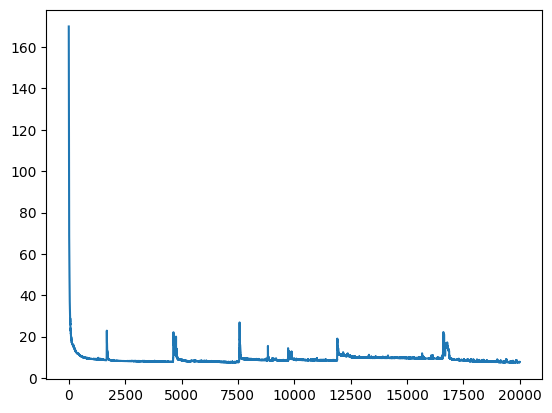

In [660]:
#plot the mean square error in each epoch/iteration
plt.plot(np.arange(len(losslist)),losslist)
plt.show()

In [661]:
#save the best neural network model you have obtained.
torch.save(model.state_dict(), 'best_nn_model.pth')

#Save the mean and standard deviation of the train set inputs because we need to use them at test time.

In [662]:
#reload the your best neural network model with saved parameters
model = NN(n_feature=2,n_hidden1=31,n_hidden2=13, n_output=1)
model.load_state_dict(torch.load('best_nn_model.pth'))

RuntimeError: Error(s) in loading state_dict for NN:
	size mismatch for hidden1.weight: copying a param with shape torch.Size([100, 2]) from checkpoint, the shape in current model is torch.Size([31, 2]).
	size mismatch for hidden1.bias: copying a param with shape torch.Size([100]) from checkpoint, the shape in current model is torch.Size([31]).
	size mismatch for bn1.running_mean: copying a param with shape torch.Size([100]) from checkpoint, the shape in current model is torch.Size([31]).
	size mismatch for bn1.running_var: copying a param with shape torch.Size([100]) from checkpoint, the shape in current model is torch.Size([31]).
	size mismatch for hidden2.weight: copying a param with shape torch.Size([32, 100]) from checkpoint, the shape in current model is torch.Size([13, 31]).
	size mismatch for hidden2.bias: copying a param with shape torch.Size([32]) from checkpoint, the shape in current model is torch.Size([13]).
	size mismatch for bn2.running_mean: copying a param with shape t

In [ ]:
#Extract inputs of the test_set
test_set_inputs = test_set[:,:2]
#Extract test set targets from the test_set
test_set_targets = test_set[:,2][:,np.newaxis]

In [ ]:
mean_of_test_input = torch.mean(test_set_inputs)
#standard deviation of the test set inputs.
std_of_the_test_input = torch.std(test_set_inputs,0)

In [ ]:
#Normalize test set inputs by using the mean and standard deviation of the inputs of the training set
normalized_test_set_inputs = (test_set_inputs - mean_of_test_input)/std_of_the_test_input

In [ ]:
#feed the normalized test set inputs to the Neural Network model and obtain the prediction for the test set.
prediction_test = model(normalized_test_set_inputs)

In [ ]:
print(prediction_test.shape)

torch.Size([185, 1])


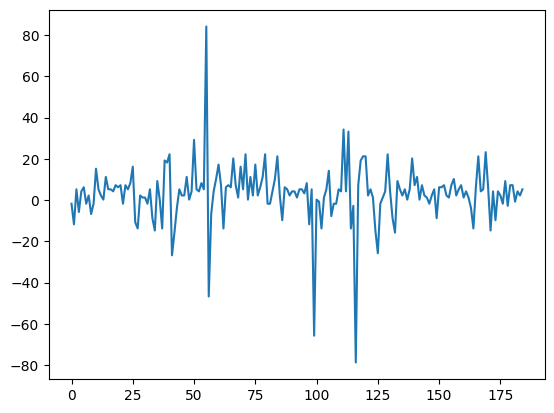

In [ ]:
#plot the prediction error of the test set
test_set_prediction_error = prediction_test - test_set_targets
plt.plot(np.arange(len(test_set_prediction_error.tolist())),test_set_prediction_error.tolist())

In [ ]:
torch.mean(test_set_prediction_error)

tensor(3.1385, grad_fn=<MeanBackward0>)